# RF-Based Drone Signal Detection

**Module 20 Initial Report and Exploratory Data Analysis**

This project asks: **Can a supervised machine-learning model detect drone-associated radio-frequency (RF) activity while keeping the false-positive rate at or below 5%?**

The original Module 16 proposal named CardRF, but that dataset was not accessible. The project therefore pivots to the public [Noisy Drone RF Signal Classification dataset](https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification). The research question and binary-classification design remain unchanged; only the primary data source changes.

**Target**
- `1`: drone-associated RF signal
- `0`: RF background/noise

**Why it matters:** RF detection can complement visual detection when drones are distant, obscured, or operating in low light. A useful detector must balance drone recall with a low false-alarm rate.


## 1. Setup and reproducibility

This first code cell imports the Python tools used in the notebook and tells Python where the project files are located. A **manifest** is simply a table that lists every sample and its label, file path, and data split. The notebook reads saved experiment results so the numbers shown here match the completed model run.

### Helpful vocabulary

- **Feature:** a number used by a model to make a prediction.
- **Label/target:** the correct answer the model is trying to predict.
- **Training set:** examples used to teach the model.
- **Validation set:** examples used to compare models and choose settings.
- **Test set:** untouched examples used only for the final evaluation.
- **SNR:** signal-to-noise ratio; lower values mean the signal is harder to distinguish from noise.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sns.set_theme(style="whitegrid", context="notebook")
artifact_dir = PROJECT_ROOT / "reports" / "artifacts" / "noisy_drone_rf"

required = [artifact_dir / "model_comparison.csv", artifact_dir / "test_metrics.json",
            artifact_dir / "test_predictions.csv", artifact_dir / "metrics_by_snr.csv"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required capstone artifact(s):\n" + "\n".join(missing))

test_predictions = pd.read_csv(artifact_dir / "test_predictions.csv")
print(f"Project root: {PROJECT_ROOT}")
print(f"Saved test predictions: {len(test_predictions):,} rows")


Project root: /Users/privateaya_1/Documents/berkeley_capstone
Saved test predictions: 1,400 rows


## 2. Data source and structure

The primary dataset contains RF in-phase/quadrature (I/Q) samples across seven original labels: six drone/controller classes and one noise class. I/Q values are two numerical parts used to represent a radio signal. The full downloaded archive contains 98,705 examples with SNR values from -20 dB to 30 dB. To make the experiment manageable on a personal computer, I selected 1,000 observations per original class (7,000 total).

The manifest records one row per model input with its source, recording identifier, local path, original class, binary label, split, and signal-to-noise ratio (SNR). `Noise` maps to 0; all controller/drone-associated classes map to 1.

A small DroneRF subset is retained only as an external domain-shift check. It is not mixed into primary training or test data because its collection and representation differ.


In [2]:
data_dictionary = pd.DataFrame({
    "field": ["sample_id", "original_label", "binary_label", "snr", "split"],
    "meaning": ["Unique example ID", "Original RF class", "0=noise, 1=drone-associated",
                "Signal-to-noise ratio in dB", "train, validation, or test"]
})
display(data_dictionary)
display(test_predictions.head())
print(f"Missing values in saved test results: {test_predictions.isna().sum().sum()}")
print(f"Duplicate test sample IDs: {test_predictions['sample_id'].duplicated().sum()}")


,field,meaning
0,sample_id,Unique example ID
1,original_label,Original RF class
2,binary_label,"0=noise, 1=drone-associated"
3,snr,Signal-to-noise ratio in dB
4,split,"train, validation, or test"


,sample_id,binary_label,source,recording_id,original_label,snr,p_drone_associated,predicted_label,decision_threshold
0,noisy_drone_rf_000008,1,noisy_drone_rf,noisy_drone_rf_000008,DJI,-18,0.153151,0,0.529763
1,noisy_drone_rf_000014,1,noisy_drone_rf,noisy_drone_rf_000014,DJI,18,0.997908,1,0.529763
2,noisy_drone_rf_000015,1,noisy_drone_rf,noisy_drone_rf_000015,DJI,22,0.999778,1,0.529763
3,noisy_drone_rf_000017,1,noisy_drone_rf,noisy_drone_rf_000017,DJI,12,0.946093,1,0.529763
4,noisy_drone_rf_000019,1,noisy_drone_rf,noisy_drone_rf_000019,DJI,-6,0.502118,0,0.529763


Missing values in saved test results: 0
Duplicate test sample IDs: 0


## 3. Exploratory data analysis

EDA means **exploratory data analysis**. In this section I check the shape and quality of the data before discussing any model results. The selected subset is balanced across the seven original labels. After conversion to the binary target, the positive class is larger because six of the seven original labels represent drone-associated activity. The train, validation, and test splits keep approximately the same class proportions.


### Data cleaning checks

Before making charts, I check for missing values and duplicate sample IDs. Missing labels, SNR values, or predictions would make the analysis unreliable. Duplicate IDs could cause the same observation to be counted more than once. The code removes duplicates and rows missing required analysis fields if any are found.


In [3]:
# Keep the original saved results unchanged and clean a copy for analysis.
analysis_data = test_predictions.copy()
required_columns = ["sample_id", "binary_label", "snr", "p_drone_associated", "predicted_label"]

missing_before = analysis_data[required_columns].isna().sum()
duplicates_before = analysis_data["sample_id"].duplicated().sum()

analysis_data = analysis_data.drop_duplicates(subset="sample_id")
analysis_data = analysis_data.dropna(subset=required_columns)

cleaning_summary = pd.DataFrame({
    "check": ["Missing required values", "Duplicate sample IDs", "Rows removed"],
    "count": [missing_before.sum(), duplicates_before, len(test_predictions) - len(analysis_data)],
})
display(cleaning_summary)
print(f"Rows available after cleaning: {len(analysis_data):,}")


,check,count
0,Missing required values,0
1,Duplicate sample IDs,0
2,Rows removed,0


Rows available after cleaning: 1,400


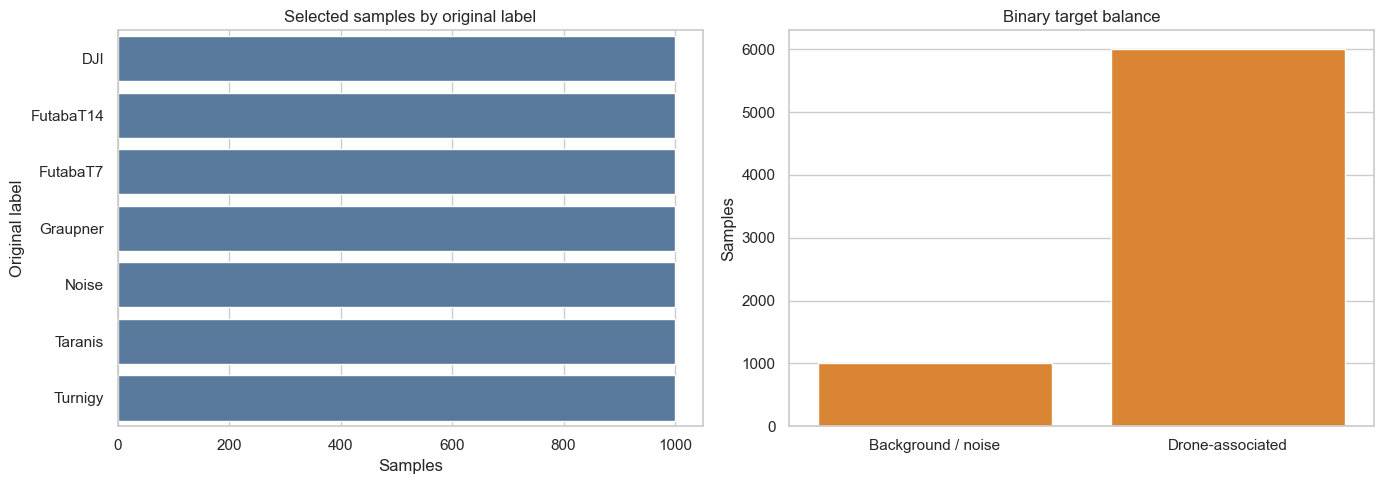

In [4]:
original_counts = pd.DataFrame({
    "original_label": ["DJI", "FutabaT14", "FutabaT7", "Graupner", "Noise", "Taranis", "Turnigy"],
    "samples": [1000] * 7
})
binary_counts = pd.DataFrame({"class": ["Background / noise", "Drone-associated"], "samples": [1000, 6000]})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=original_counts, y="original_label", x="samples", color="#4C78A8", ax=axes[0])
axes[0].set(title="Selected samples by original label", xlabel="Samples", ylabel="Original label")
sns.barplot(data=binary_counts, x="class", y="samples", color="#F58518", ax=axes[1])
axes[1].set(title="Binary target balance", xlabel="", ylabel="Samples")
plt.tight_layout()
plt.show()


,split,Background / noise,Drone-associated,total
0,train,600,3600,4200
1,validation,200,1200,1400
2,test,200,1200,1400


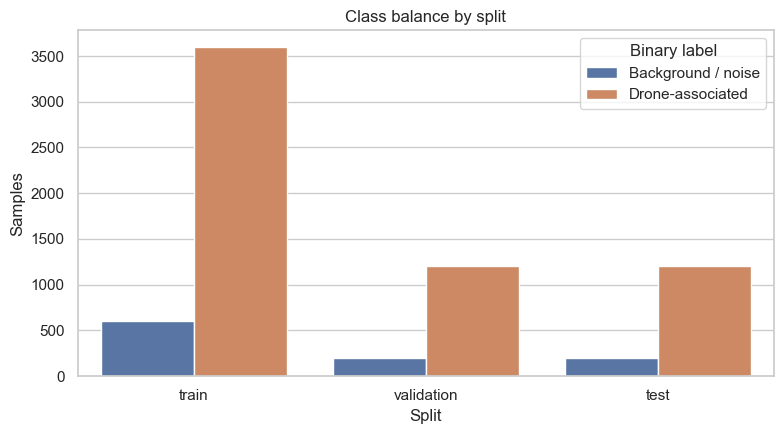

In [5]:
split_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "Background / noise": [600, 200, 200],
    "Drone-associated": [3600, 1200, 1200],
})
split_table["total"] = split_table["Background / noise"] + split_table["Drone-associated"]
display(split_table)
plot_splits = split_table.melt(id_vars=["split", "total"], value_vars=["Background / noise", "Drone-associated"],
                               var_name="class", value_name="samples")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=plot_splits, x="split", y="samples", hue="class", ax=ax)
ax.set(title="Class balance by split", xlabel="Split", ylabel="Samples")
ax.legend(title="Binary label")
plt.tight_layout()
plt.show()


### Signal-to-noise ratio

SNR measures signal strength relative to background noise. Lower values represent harder detection conditions. The dataset spans -20 to 30 dB, allowing performance to be evaluated across easy and difficult RF conditions.


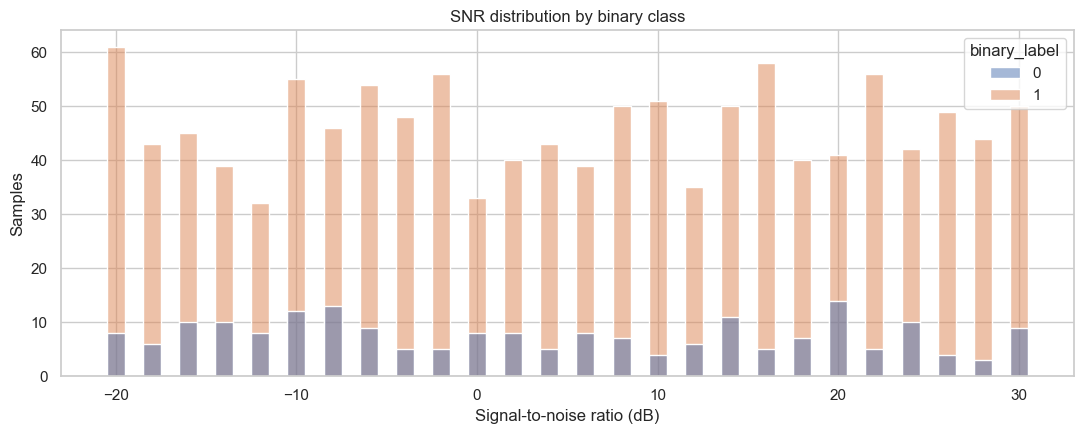

,count,min,median,max
binary_label,,,,
Background / noise,200,-20,2.0,30
Drone-associated,1200,-20,6.0,30


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(data=analysis_data, x="snr", hue="binary_label", multiple="layer", discrete=True, ax=ax)
ax.set(title="SNR distribution by binary class", xlabel="Signal-to-noise ratio (dB)", ylabel="Samples")
plt.tight_layout()
plt.show()

display(analysis_data.groupby("binary_label")["snr"].agg(["count", "min", "median", "max"]).rename(index={0:"Background / noise", 1:"Drone-associated"}))


### Outlier and anomaly analysis

An outlier is a value far from most other observations. I use the interquartile range (IQR) rule to flag unusually low or high SNR values. I do not automatically remove a flagged SNR because the dataset was intentionally collected at controlled levels from -20 to 30 dB; difficult low-SNR signals are important to the research question. I also verify that every predicted probability is between 0 and 1.


SNR IQR limits: -47.0 to 57.0 dB
SNR values flagged by the IQR rule: 0
Probabilities outside 0 to 1: 0


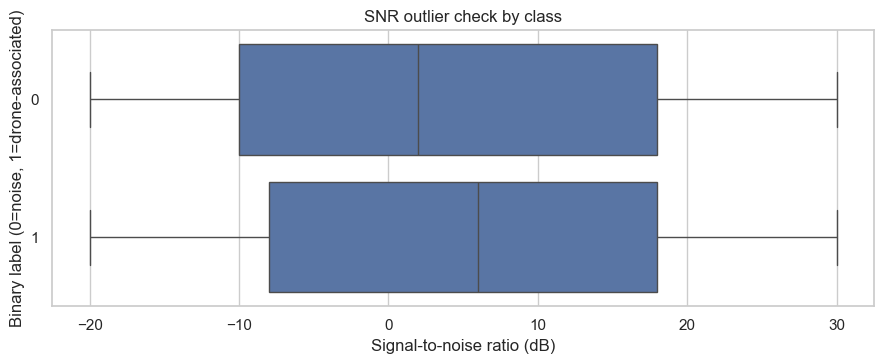

In [7]:
q1 = analysis_data["snr"].quantile(0.25)
q3 = analysis_data["snr"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
snr_outliers = analysis_data[~analysis_data["snr"].between(lower_limit, upper_limit)]
invalid_probabilities = (~analysis_data["p_drone_associated"].between(0, 1)).sum()

print(f"SNR IQR limits: {lower_limit:.1f} to {upper_limit:.1f} dB")
print(f"SNR values flagged by the IQR rule: {len(snr_outliers)}")
print(f"Probabilities outside 0 to 1: {invalid_probabilities}")

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.boxplot(data=analysis_data, x="snr", y="binary_label", orient="h", ax=ax)
ax.set(title="SNR outlier check by class", xlabel="Signal-to-noise ratio (dB)",
       ylabel="Binary label (0=noise, 1=drone-associated)")
plt.tight_layout()
plt.show()


### Representative signal transformation

Raw I/Q values were converted to normalized log-spectrograms. A spectrogram represents frequency content over time. The table below summarizes the transformation in plain language. Raw signal files are not stored on GitHub because they are very large; the notebook uses the saved, shareable experiment results.


In [8]:
feature_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "input/output": ["Raw I/Q values", "Log-spectrogram", "10 summary features", "Model prediction"],
    "purpose": ["Represent the RF signal", "Show frequency over time",
                "Create a small numerical model input", "Estimate drone-associated probability"]
})
display(feature_steps)


,step,input/output,purpose
0,1,Raw I/Q values,Represent the RF signal
1,2,Log-spectrogram,Show frequency over time
2,3,10 summary features,Create a small numerical model input
3,4,Model prediction,Estimate drone-associated probability


### Feature engineering for interpretation

Feature engineering means creating useful variables from existing data. For model training, the main engineered inputs were ten spectral summaries extracted from each spectrogram. For EDA, I create two easy-to-interpret variables: whether each prediction was correct and a signal-quality group based on SNR. These variables help show the relationship between signal quality and model success.


,signal_quality_group,samples,prediction_accuracy
0,Low (<0 dB),565,27.8%
1,Moderate (0-5 dB),137,89.1%
2,Strong (6+ dB),698,98.6%


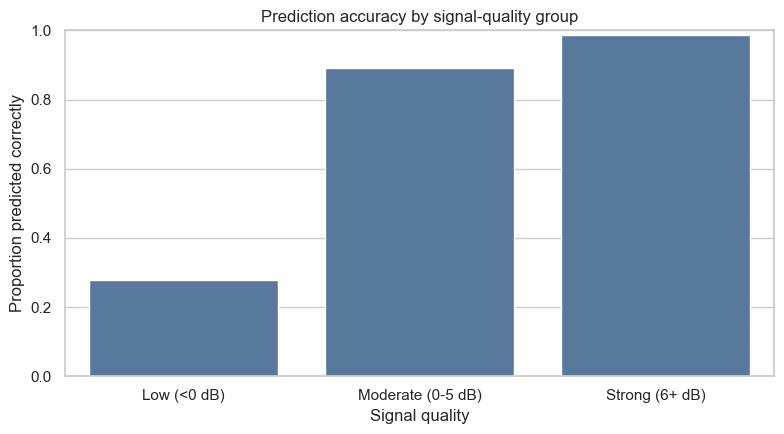

In [9]:
analysis_data["correct_prediction"] = (analysis_data["binary_label"] == analysis_data["predicted_label"])
analysis_data["signal_quality_group"] = pd.cut(
    analysis_data["snr"],
    bins=[-np.inf, -1, 5, np.inf],
    labels=["Low (<0 dB)", "Moderate (0-5 dB)", "Strong (6+ dB)"],
)
quality_summary = analysis_data.groupby("signal_quality_group", observed=True).agg(
    samples=("sample_id", "count"),
    prediction_accuracy=("correct_prediction", "mean"),
).reset_index()
display(quality_summary.style.format({"prediction_accuracy": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=quality_summary, x="signal_quality_group", y="prediction_accuracy", color="#4C78A8", ax=ax)
ax.set(title="Prediction accuracy by signal-quality group", xlabel="Signal quality",
       ylabel="Proportion predicted correctly", ylim=(0, 1))
plt.tight_layout()
plt.show()


## 4. Data preparation

Preprocessing means changing the raw data into a consistent form that a model can use. My workflow is:

1. Read I/Q arrays from the downloaded PyTorch archive and save the selected observations as NumPy files.
2. Validate required manifest fields, labels, file paths, and split assignments.
3. Keep each `recording_id` in exactly one split to reduce leakage risk.
4. Convert each signal to a normalized log-spectrogram.
5. Extract ten compact spectral summary features for classical baselines.
6. Train on the training split, choose model and threshold on validation data, and evaluate once on held-out test data.

No target encoding is needed beyond mapping `Noise → 0` and all six drone/controller labels `→ 1`. The signal arrays are numerical and contain no tabular missing values. Normalization occurs at the spectrogram level.


## 5. Modeling and validation

Supervised learning means the models learn from examples that already have correct labels. I compared two common classifiers:

- **Logistic regression:** interpretable linear baseline with regularization.
- **Random forest:** nonlinear tree ensemble that can model feature interactions.

A model first produces a probability. A **threshold** turns that probability into a 0 or 1 prediction. Instead of automatically using 0.5, I used validation data to choose a threshold that maximizes recall while requiring false-positive rate (FPR) ≤ 5%. Recall measures how many real drone-associated examples were detected. FPR measures how often real background examples were incorrectly flagged.


In [10]:
model_comparison = pd.read_csv(artifact_dir / "model_comparison.csv")
display(model_comparison.style.format({
    "validation_threshold": "{:.3f}",
    "validation_recall": "{:.3f}",
    "validation_precision": "{:.3f}",
    "validation_fpr": "{:.3f}",
    "validation_f1": "{:.3f}",
    "validation_pr_auc": "{:.3f}",
}))

selected = model_comparison.sort_values(
    ["validation_recall", "validation_pr_auc", "validation_f1"], ascending=False
).iloc[0]
print(f"Selected model: {selected['model']}")
print(f"Validation-selected threshold: {selected['validation_threshold']:.3f}")


,model,validation_threshold,validation_recall,validation_precision,validation_fpr,validation_f1,validation_pr_auc
0,logistic_regression,0.530,0.673,0.988,0.050,0.801,0.981
1,random_forest,0.952,0.666,0.988,0.050,0.795,0.985


Selected model: logistic_regression
Validation-selected threshold: 0.530


## 6. Held-out test results

The selected logistic regression model met the false-positive limit on the held-out test set. Precision was 99.1%, meaning positive alerts were usually correct. Recall was 64.5%, meaning the model still missed about 35 out of every 100 drone-associated examples. The confusion matrix below shows the counts behind these metrics.


,metric,value
0,threshold,0.530
1,recall,0.645
2,precision,0.991
3,f1,0.781
4,fpr,0.035
5,pr_auc,0.984
6,roc_auc,0.910
7,true_negative,193.000
8,false_positive,7.000
9,false_negative,426.000


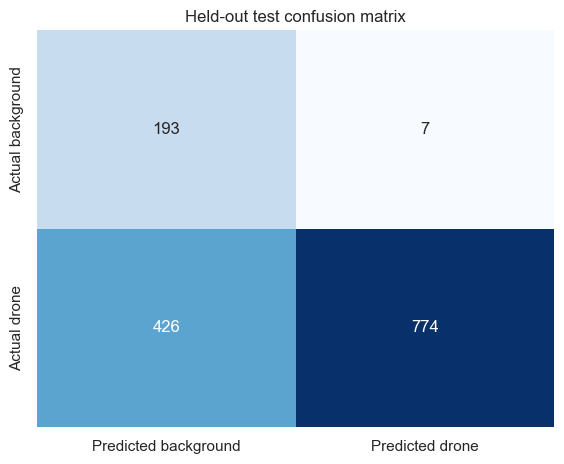

In [11]:
with open(artifact_dir / "test_metrics.json") as f:
    test_metrics = json.load(f)

metric_order = ["threshold", "recall", "precision", "f1", "fpr", "pr_auc", "roc_auc",
                "true_negative", "false_positive", "false_negative", "true_positive"]
metrics_display = pd.DataFrame({
    "metric": metric_order,
    "value": [test_metrics[k] for k in metric_order],
})
display(metrics_display.style.format({"value": "{:.3f}"}))

cm = np.array([
    [test_metrics["true_negative"], test_metrics["false_positive"]],
    [test_metrics["false_negative"], test_metrics["true_positive"]],
])
fig, ax = plt.subplots(figsize=(5.8, 4.8))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", cbar=False,
            xticklabels=["Predicted background", "Predicted drone"],
            yticklabels=["Actual background", "Actual drone"], ax=ax)
ax.set_title("Held-out test confusion matrix")
plt.tight_layout()
plt.show()


### Performance by SNR

The aggregate result hides the strongest finding: performance depends heavily on signal quality. Recall is poor at strongly negative SNR and rises sharply near 0 dB. At 6 dB and above, recall is generally near 1.0 in this test sample.


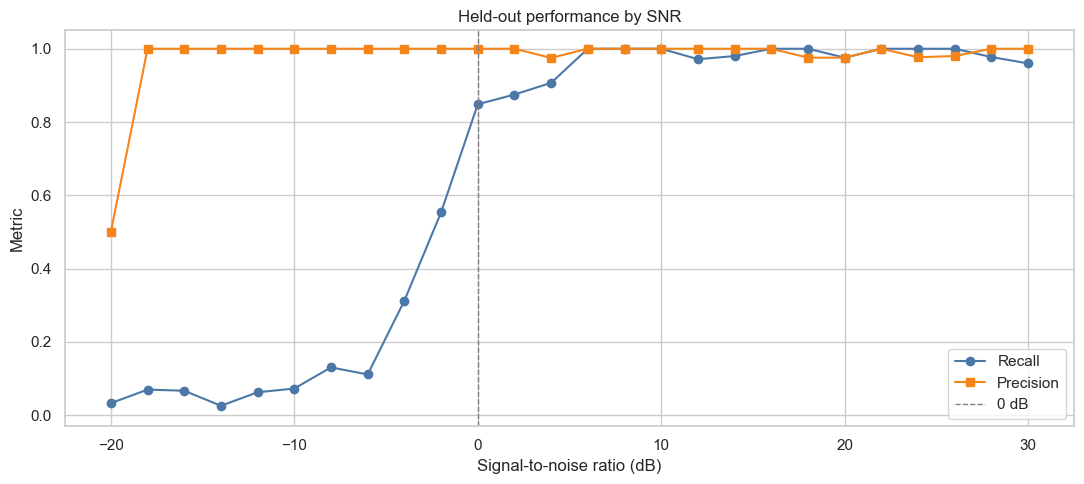

,snr,rows,recall,precision,fpr
0,-20,69,0.033,0.500,0.250
1,-18,49,0.070,1.000,0.000
2,-16,55,0.067,1.000,0.000
3,-14,49,0.026,1.000,0.000
4,-12,40,0.062,1.000,0.000
5,-10,67,0.073,1.000,0.000
6,-8,59,0.130,1.000,0.000
7,-6,63,0.111,1.000,0.000
8,-4,53,0.312,1.000,0.000
9,-2,61,0.554,1.000,0.000


In [12]:
snr_metrics = pd.read_csv(artifact_dir / "metrics_by_snr.csv").sort_values("snr")
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(snr_metrics["snr"], snr_metrics["recall"], marker="o", label="Recall", color="#4C78A8")
ax.plot(snr_metrics["snr"], snr_metrics["precision"], marker="s", label="Precision", color="#F58518")
ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="0 dB")
ax.set(title="Held-out performance by SNR", xlabel="Signal-to-noise ratio (dB)", ylabel="Metric", ylim=(-0.03, 1.05))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(snr_metrics[["snr", "rows", "recall", "precision", "fpr"]].style.format({
    "recall": "{:.3f}", "precision": "{:.3f}", "fpr": "{:.3f}"
}))


## 7. Conclusions, limitations, and next steps

**Answer to the research question:** Yes, the model can identify drone-associated RF activity under the measured conditions while holding test FPR to 3.5%. However, the 64.5% overall recall is not sufficient for a high-stakes operational detector. The model is reliable mainly at moderate-to-high SNR and misses many weak signals.

**Key findings**
- Logistic regression slightly exceeded random forest validation recall under the 5% FPR constraint.
- Test precision was 99.1%, so positive alerts were usually correct in this held-out sample.
- Detection quality changed dramatically with SNR; low-SNR signals caused most misses.
- The CardRF-to-Noisy-Drone-RF pivot preserved the binary research question and made the analysis reproducible with an accessible public dataset.

**Limitations**
- The 7,000-sample capstone subset is balanced by original label and does not reflect real-world class prevalence.
- Public laboratory data may not represent unseen hardware, locations, interference, frequencies, or RF-silent/autonomous drones.
- The small DroneRF external check showed poor transfer at the selected threshold; its sample is too small for a definitive benchmark but signals domain shift.
- A random split by individual examples can still overstate generalization if collection sessions share hidden similarities. The manifest enforces unique recording identifiers, but richer session metadata would strengthen leakage controls.

**Next steps**
1. Expand external testing with a larger, harmonized DroneRF subset.
2. Add a compact CNN and compare it under the same validation FPR constraint.
3. Improve low-SNR robustness using augmentation, denoising, class/SNR weighting, or specialized features.
4. Calibrate probabilities and test operating thresholds across deployment-like RF environments.

This is an academic research prototype for defensive RF awareness, not a deployed safety or enforcement system.
